# L5 · Lab A — Build a Reward Model from Human Preferences

**RL for LLMs / RLHF — Vizuara AI Labs · Dr. Rajat Dandekar**

In the lecture we said: *there is no formula for a "good" answer, so we **learn** one from human comparisons.* This lab builds that learned reward model from scratch on the real **Anthropic HH-RLHF** preference data.

You will:
1. Load real human preference pairs `(prompt, chosen, rejected)`.
2. Put a **scalar head** on a transformer (gpt2) — the lecture's "swap the language head for a head that outputs one number."
3. Train it with the **Bradley-Terry** loss so it scores the *chosen* answer above the *rejected* one (**your one job**).
4. Watch preference accuracy climb above chance.

> Runtime: **GPU** (Runtime → Change runtime type → T4). ~10 minutes.


In [2]:
# ✅ PROVIDED — setup
!pip -q install "transformers==4.45.2" "datasets==3.0.1" >/dev/null
import torch, torch.nn.functional as F, random
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
device: cuda


## 1 · The data — real human preferences

Each row of HH-RLHF is two full conversations that share a prompt and differ in the assistant's reply: a **chosen** (human-preferred) one and a **rejected** one.

In [3]:
# ✅ PROVIDED — load a slice of Anthropic HH-RLHF
ds = load_dataset("Anthropic/hh-rlhf", split="train").shuffle(seed=0)
train = ds.select(range(8000))
test  = ds.select(range(8000, 8800))

ex = train[0]
print("CHOSEN  (preferred):\n", ex["chosen"][-400:])
print("\nREJECTED:\n", ex["rejected"][-400:])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

CHOSEN  (preferred):
 )

Human: What is the plot of Cast Away?

Assistant: It’s about a FedEx worker who's survived a plane crash and washed up on an island.

Human: Which movie would you most recommend from the list above?

Assistant: I really enjoyed A League of Their Own, although it's kind of dated.  Forrest Gump is also good, but I liked it less.  For me, The Green Mile was the best movie of the ones listed above.

REJECTED:
 n Mile  (1999)
-  Sling Blade  (1996)
- Saving Private Ryan  (1998)
- You've Got Mail  (1998)
- Angels in America  (2003)
- The Da Vinci Code  (2006)

Human: What is the plot of Cast Away?

Assistant: It’s about a FedEx worker who's survived a plane crash and washed up on an island.

Human: Which movie would you most recommend from the list above?

Assistant: I think The Green Mile is really good.


## 2 · The model — a transformer with a scalar head

A reward model is just a transformer whose language head is replaced by a **single linear layer to one number**. In 🤗 Transformers that is exactly `AutoModelForSequenceClassification(..., num_labels=1)`.

**Why left-truncation?** The chosen and rejected texts share the prompt and differ in the assistant's reply *at the end*. If we truncated from the right we'd cut off the very part that differs. So we keep the **end**.

In [4]:
# ✅ PROVIDED — tokenizer + transformer-with-a-scalar-head (with detailed comments and explanation)

# Load the GPT-2 tokenizer from Hugging Face Transformers.
# The tokenizer converts raw text into token IDs that the model understands.
tok = AutoTokenizer.from_pretrained("gpt2")

# Set the tokenizer's padding token to be the same as the EOS (end-of-sequence) token.
# GPT-2 doesn't use a pad token by default, so we manually set it.
tok.pad_token = tok.eos_token

# Specify truncation from the left. This ensures that if the input is too long,
# the *beginning* of the text is truncated off (not the end).
# This is important because, in human preference pairs, the *ending* is where
# the model responses actually differ. Truncating from the right (default) would cut
# off the interesting part where chosen/rejected differ!
tok.truncation_side = "left"

# Initialize the reward model. This is a GPT-2 transformer with its language
# modeling head swapped for a scalar regression/classification head.
#
# - from_pretrained("gpt2"): Loads the base GPT-2 weights.
# - num_labels=1: Sets the classification head to output a single scalar (the "reward").
#   Normally, a classifier might output logits over classes, but here we want a
#   *single* score per input.
model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=1)

# Make sure the model configuration uses our padding token.
model.config.pad_token_id = tok.eos_token_id

# Move the model to the appropriate device (GPU, Apple MPS, or CPU).
model.to(device)

# Define maximum tokenized input length and batch size for processing.
MAX_LEN, BS = 512, 8

def score(texts):
    """
    Returns the scalar reward score for each input text.
    Uses the tokenizer to process `texts` into padded, truncated batches,
    encodes them as tensors, and moves them to the computation device.
    The model returns logits for each, which are squeezed into 1D (one value per input).
    """
    enc = tok(
        texts,                    # batch of input strings
        return_tensors="pt",      # return PyTorch tensors
        padding=True,             # pad to max length in batch
        truncation=True,          # enable truncation for long inputs
        max_length=MAX_LEN        # cut off inputs longer than MAX_LEN tokens
    ).to(device)                  # move encoded data to computation device

    # Forward pass: model(**enc) outputs dict; logits shape [batch, 1].
    # Squeeze out the last dimension so we have [batch] scalar rewards.
    return model(**enc).logits.squeeze(-1)   # one scalar reward per text

# Print how many parameters (in millions) are in the model.
print("reward model ready — params:", sum(p.numel() for p in model.parameters())//1_000_000, "M")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


reward model ready — params: 124 M


## 3 · Evaluation — preference accuracy

A reward model is "good" if it scores the chosen answer above the rejected one. On a random model that happens ~50% of the time.

In [5]:
# ✅ PROVIDED — accuracy = fraction of test pairs where r(chosen) > r(rejected)
@torch.no_grad()  # Disable gradient computation for evaluation (saves memory & speeds up)
def eval_acc():
    """
    Computes the accuracy of the reward model on the test preference dataset.
    Accuracy is defined as the fraction of test pairs for which the reward score
    assigned to the 'chosen' answer is higher than the score assigned to the 'rejected' answer.

    Returns:
        accuracy (float): Proportion of pairs where r(chosen) > r(rejected)
    """
    model.eval()  # Set the model to evaluation mode (disables dropout, etc.)
    correct = 0   # Counter for number of correct predictions
    total = 0     # Counter for total number of pairs evaluated

    # Process the test set in batches to avoid memory issues.
    # 'BS' = batch size; loop from i=0 to len(test), stepping by batch size
    for i in range(0, len(test), BS):
        # Get batch of 'chosen' and 'rejected' texts
        # score(...) returns a tensor of model-assigned scalar rewards for inputs
        rc = score(test["chosen"][i:i+BS])    # Reward scores for chosen responses
        rr = score(test["rejected"][i:i+BS])  # Reward scores for rejected responses

        # Compare the scores: (rc > rr) gives a boolean tensor; sum counts the True values
        correct += (rc > rr).sum().item()     # Increment correct by number of correct comparisons in batch

        # Each batch may have fewer than BS elements in the last batch, so use actual length
        total += len(rc)                      # Increment total by batch size (or actual # in final partial batch)

    model.train()  # Restore training mode (important for further optimization steps)
    return correct / total  # Compute and return accuracy as a float

# Before training, reward model is untrained/random — accuracy should be around 0.50 (chance)
print("accuracy BEFORE training:", round(eval_acc(), 4))   # e.g., ~0.50 (chance)

accuracy BEFORE training: 0.5138


## 4 · 📝 TODO — the Bradley-Terry loss

This is the heart of the lab. We want **P(chosen ≻ rejected) = σ(r_chosen − r_rejected)** to be large. Maximizing its log-likelihood = minimizing `−log σ(r_chosen − r_rejected)`.

Implement that one line. *(Hint: `F.logsigmoid`.)*

In [6]:
def bradley_terry_loss(r_chosen, r_rejected):
    """
    Computes the Bradley-Terry loss for a batch of (chosen, rejected) reward model scores.

    In the Bradley-Terry (BT) model for paired comparison, we want the model to assign a higher reward
    to the 'chosen' output than to the 'rejected' one. Formally, the probability of preferring 'chosen'
    over 'rejected' is modeled as:

        P(chosen ≻ rejected) = σ(r_chosen - r_rejected)

    where σ is the sigmoid function:

        σ(x) = 1 / (1 + exp(-x))

    To train the model, we maximize the likelihood of correct preferences, or equivalently,
    minimize the negative log-likelihood. The loss for each pair is:

        -log(σ(r_chosen - r_rejected))

    For numerical stability and convenient backprop with batched tensors, we use `F.logsigmoid`, which computes
    log(sigmoid(x)) in a stable way and supports vectorized operations over batches.

    Args:
        r_chosen (torch.Tensor): Tensor of scalar rewards for 'chosen' responses (batch)
        r_rejected (torch.Tensor): Tensor of scalar rewards for 'rejected' responses (batch)

    Returns:
        torch.Tensor: The mean loss over the batch (scalar), where lower is better (loss is minimized
                      when r_chosen ≫ r_rejected for correct pairs).
    """
    # Compute the margin: difference between rewards assigned to chosen and rejected outputs
    margin = r_chosen - r_rejected  # shape: (batch_size,)

    # Compute the Bradley-Terry loss:
    #   -F.logsigmoid(margin) gives the negative log probability,
    #   which penalizes the model if the chosen response is not sufficiently
    #   preferred over the rejected one.
    loss = -F.logsigmoid(margin)  # shape: (batch_size,)

    # Take the mean loss over the batch (scalar)
    # This is standard for loss computation in PyTorch training loops
    return loss.mean()

In [7]:
# ✅ PROVIDED — training loop (calls your loss)
# Create the AdamW optimizer for model parameters with a (small) learning rate appropriate for fine-tuning
opt = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Build a shuffled index list for training data
# (This ensures batches are sampled in random order, as is typical for SGD)
idx = list(range(len(train)))         # idx = [0, 1, ..., N-1]; corresponds to training examples
random.seed(0)                       # Set seed for reproducibility (same shuffle every run)
random.shuffle(idx)                   # Shuffle order for stochasticity (improves generalization!)

# Store accuracy trajectory so we can plot how preference accuracy improves over training
acc_curve = [(0, eval_acc())]         # (step=0, initial accuracy)
step = 0                              # Step counter

# Main training loop
# We process all training data in batches of size BS
for i in range(0, len(idx), BS):
    b = idx[i:i+BS]                   # Get current minibatch indices from shuffled idx list

    # Compute scalar 'reward' scores for the batch of 'chosen' and 'rejected' responses
    # Each of the following is a tensor of shape (batch_size,)
    rc = score([train["chosen"][j]   for j in b])    # Model's score for "chosen" responses
    rr = score([train["rejected"][j] for j in b])    # Model's score for "rejected" responses

    # Compute the Bradley-Terry loss for this batch:
    #   - Encourages higher reward for chosen vs rejected
    loss = bradley_terry_loss(rc, rr)            # <-- your implementation from previous cell

    # Backpropagation and optimization step
    opt.zero_grad()     # Clear existing gradients on model parameters
    loss.backward()     # Compute new gradients (backward pass)
    opt.step()          # Update model parameters based on gradients
    step += 1           # Increment step counter

    # Every 100 steps: compute/record evaluation accuracy and print progress
    if step % 100 == 0:
        a = eval_acc()                               # Evaluate preference accuracy on val split (or test set)
        acc_curve.append((step, a))                  # Log accuracy for plotting
        # Print step information:
        # - Current loss
        # - Avg. margin (how much 'chosen' is preferred over 'rejected')
        # - Accuracy
        print(f"step {step:4d}  loss {loss.item():.4f}  margin {(rc-rr).mean():+.3f}  acc {a:.4f}")

# Final evaluation: report accuracy after all training steps are finished
print("accuracy AFTER training:", round(eval_acc(), 4))

step  100  loss 0.5955  margin +0.277  acc 0.5675
step  200  loss 0.6745  margin +0.061  acc 0.5650
step  300  loss 0.6557  margin +0.115  acc 0.5763
step  400  loss 0.6321  margin +0.147  acc 0.5875
step  500  loss 0.6240  margin +0.181  acc 0.5900
step  600  loss 0.7006  margin +0.036  acc 0.5687
step  700  loss 0.7054  margin +0.007  acc 0.5713
step  800  loss 0.7077  margin -0.006  acc 0.5713
step  900  loss 0.7286  margin -0.044  acc 0.5850
step 1000  loss 0.5945  margin +0.298  acc 0.5900
accuracy AFTER training: 0.59


## 5 · Results

Plot the accuracy curve. On gpt2-small over the full HH mix you should reach **~0.57–0.60** — clearly above the 0.50 chance line. (Bigger models + more data push this higher; the point is that a *single scalar* learned purely from comparisons captures human preference.)

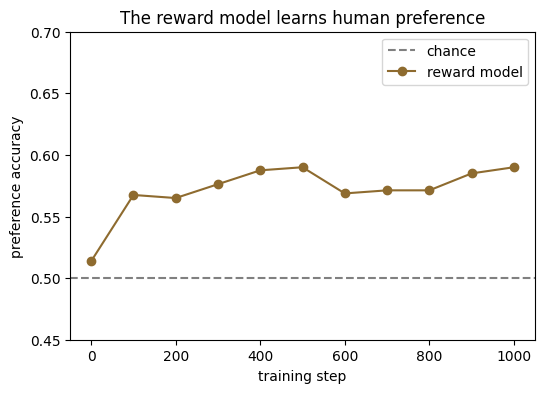

In [8]:
# ✅ PROVIDED — plot the climb
import matplotlib.pyplot as plt
xs, ys = zip(*acc_curve)
plt.figure(figsize=(6,4))
plt.axhline(0.5, ls="--", c="gray", label="chance")
plt.plot(xs, ys, "-o", c="#8E6B2F", label="reward model")
plt.xlabel("training step"); plt.ylabel("preference accuracy"); plt.ylim(0.45, 0.7)
plt.title("The reward model learns human preference"); plt.legend(); plt.show()

## 6 · Questions to answer

1. The loss only uses the **difference** `r_chosen − r_rejected`. What does that say about the absolute reward values — and why will we need to **normalize** rewards before using them in PPO?
2. We left-truncated the input. Predict what happens to the final accuracy if you switch to `truncation_side="right"`. (Try it.)
3. Accuracy plateaus well below 100%. Name two reasons (think: model size, label noise in human preferences).
4. **Save your reward model** (`model.save_pretrained("rm")`) — you'll plug it into the flagship RLHF project as the reward signal.


### Answers

**Q1 — The loss only uses the difference `r_chosen − r_rejected`. What does that say about the absolute reward values — and why will we need to normalize rewards before using them in PPO?**

The Bradley-Terry loss is $-\log \sigma(r_c - r_r)$. Since only the *difference* enters the sigmoid, the absolute scale of the rewards is completely unconstrained — you can shift every reward by a constant $c$ and the loss doesn't change at all ($\sigma((r_c + c) - (r_r + c)) = \sigma(r_c - r_r)$). In practice this means the trained reward model might output numbers centred at $+500$ or $-1000$; the ranking is correct but the magnitude is arbitrary.

This matters for PPO because PPO uses the reward as a signal to scale the policy gradient. If the reward model emits extremely large (or extremely variable) absolute values, the advantage estimates blow up and training becomes unstable. **Normalizing** — subtracting the running mean and dividing by the running standard deviation — brings rewards into a well-behaved range so PPO's clipped objective stays in its designed regime.

---

**Q2 — We left-truncated the input. Predict what happens to the final accuracy if you switch to `truncation_side="right"`.**

Left-truncation keeps the **end** of the text — the assistant's reply, which is exactly where chosen and rejected responses *differ*. Right-truncation keeps the **beginning** — the shared prompt. So if we switch:

* The model mostly sees the *identical prompt* for both chosen and rejected.
* The discriminative signal (the differing reply) gets clipped off.
* Accuracy should **drop to ~0.50** (chance), since the model can no longer see what makes the two responses different.

---

**Q3 — Accuracy plateaus well below 100 %. Name two reasons.**

1. **Model capacity (size).** GPT-2 small has only 124 M parameters. It lacks the representational power to capture the subtle, contextual patterns that separate "better" from "worse" responses across a diverse preference dataset.

2. **Label noise in human preferences.** Human annotators genuinely disagree — the same pair shown to two different annotators can receive opposite labels. This creates an *irreducible error floor*: even a perfect model cannot achieve 100 % accuracy when the ground-truth labels themselves are noisy. Studies on Anthropic HH-RLHF put inter-annotator agreement well below 100 %, which directly caps the best any model can do.

---

**Q4 — Save your reward model.**

In [ ]:
model.save_pretrained("rm")
tok.save_pretrained("rm")

# zip and download to your machine
import shutil
shutil.make_archive("rm", "zip", "rm")

# from google.colab import files
# files.download("rm.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>